In [30]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import sklearn as sk
import numpy as np


In [3]:
red_wine_data = pd.read_csv("../../data/winequality-red.csv")
red_wine_data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [9]:
df_train = red_wine_data.sample(frac=0.7, random_state=0)
df_valid = red_wine_data.drop(df_train.index)

max_ = df_train.max(axis=0)
min_ = df_train.min(axis=0)

df_train = (df_train - min_) / (max_ - min_)
df_valid = (df_valid - min_) / (max_ - min_)

X_train = df_train.drop('quality', axis=1)
X_valid = df_valid.drop('quality', axis=1)

y_train = df_train['quality']
y_valid = df_valid['quality']

In [23]:
model = keras.Sequential([
    layers.Dense(512, activation="relu", input_shape=[X_train.shape[1]]),
    layers.Dense(512, activation="relu"),
    layers.Dense(1)
])

/home/abanoub/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.compile(
    optimizer="adam",
    loss="mae" #mean absoulte square
)

In [29]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    batch_size=256,
    epochs=15,
    verbose=2
)

Epoch 1/15
5/5 - 0s - 39ms/step - loss: 0.0993 - val_loss: 0.1024
Epoch 2/15
5/5 - 0s - 14ms/step - loss: 0.0984 - val_loss: 0.0987
Epoch 3/15
5/5 - 0s - 15ms/step - loss: 0.0977 - val_loss: 0.0985
Epoch 4/15
5/5 - 0s - 15ms/step - loss: 0.0973 - val_loss: 0.1025
Epoch 5/15
5/5 - 0s - 15ms/step - loss: 0.0958 - val_loss: 0.0986
Epoch 6/15
5/5 - 0s - 30ms/step - loss: 0.0957 - val_loss: 0.0979
Epoch 7/15
5/5 - 0s - 15ms/step - loss: 0.0955 - val_loss: 0.1000
Epoch 8/15
5/5 - 0s - 14ms/step - loss: 0.0955 - val_loss: 0.0993
Epoch 9/15
5/5 - 0s - 14ms/step - loss: 0.0941 - val_loss: 0.1026
Epoch 10/15
5/5 - 0s - 14ms/step - loss: 0.0940 - val_loss: 0.0975
Epoch 11/15
5/5 - 0s - 17ms/step - loss: 0.0936 - val_loss: 0.0956
Epoch 12/15
5/5 - 0s - 16ms/step - loss: 0.0933 - val_loss: 0.0952
Epoch 13/15
5/5 - 0s - 18ms/step - loss: 0.0929 - val_loss: 0.0969
Epoch 14/15
5/5 - 0s - 16ms/step - loss: 0.0917 - val_loss: 0.0978
Epoch 15/15
5/5 - 0s - 17ms/step - loss: 0.0914 - val_loss: 0.1005


<Axes: >

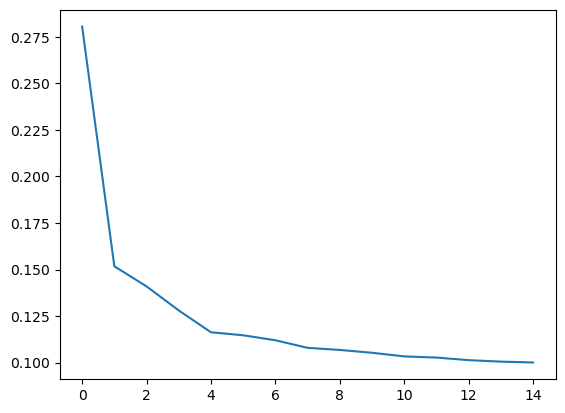

In [26]:
history_df = pd.DataFrame(history.history)
history_df["loss"].plot()

In [31]:
text_loss = model.evaluate(X_valid, y_valid)
print(f"Text Loss: {text_loss:.3f}")

predictions = model.predict(X_valid)
preds = predictions.flatten()

actual = np.array(y_valid)

for p, a in zip(preds[:5], actual[:5]):
    print(f"Predicted: {p:.3f}  Actual: {a:.3f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1005 
Text Loss: 0.101
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Predicted: 0.377  Actual: 0.400
Predicted: 0.472  Actual: 0.600
Predicted: 0.428  Actual: 0.800
Predicted: 0.435  Actual: 0.400
Predicted: 0.388  Actual: 0.400
